# Simulation of Bike Sharing

We start-off by providing a function that simulates the sequence of demand requests at a given station for each minute of the peak hour. Each simulation describes an equally-likely path describing how the inventory of bikes varies over time. For each minute of the peak hour, we generate the random number of demand requests and the random number of replenished bikes, using the function `np.random.poisson()`. Next, we calculate all the metrics of interest:
- Lost demand: If the demand is 10 and the total inventory available is 6, the lost demand is 4;
- Satisfied demand: If the demand is 10 and the total inventory available is 6, the satisfied demand is 6;
- Stock-out event: Indicates whether the inventory reaches 0.

*Execute the next cells. Feel free to modify the parameters to understand their effect.*

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt # general visualization package 
#next command allows you to display the figures in the notebook
%matplotlib inline   

def simulate_inventory(demand_rate,replenishment_rate,initial_inventory, n_sims = 100, seed = 0) :   
    '''
    Elementary function to generate simulation
    
    demand_rate -> per minute rate of demand requests (rate at which new users rent bikes from the station)
    replenishment_rate -> per minute rate of replenishment (rate at which current users return their bikes to the station)
    initial_inventory -> starting level of inventory at the station
    n_sims (optional argument) -> sample size of the simulation (number of simulated paths of the inventory over time)
    seed (optional argument) -> fixes the sequence of pseudo-random numbers
    '''
    np.random.seed(seed) # fix the randomness
    demands = np.random.poisson(demand_rate, (n_sims,60)) #number of demand arrivals in each minute of each simulation
    replenishments = np.random.poisson(replenishment_rate, (n_sims,60)) #number of bikes returned in each minute of each simulation

    simulated_inventory = np.zeros((n_sims,60))
    simulated_inventory[:,0] = initial_inventory #we set the initial inventory level
    lost_demand = np.zeros((n_sims,60)) # we store here the lost demand for each minute and simulation path
    satisfied_demand = np.zeros((n_sims,60)) # we store here the satisfied demand for each minute and simulation path
    is_stock_out = np.zeros((n_sims,60)) # we store here the state of the system ("stock-out") for each minute and simulation path
    
    for t in range(1,60):
        # we simulate each minute of the peak hour
        simulated_inventory[:,t] = np.maximum(0,simulated_inventory[:,t-1] + replenishments[:,t] - demands[:,t])      
        # we calculate the lost demand assuming replenishment happens before the demand
        lost_demand[:,t] = np.maximum(0, demands[:,t] - replenishments[:,t] - simulated_inventory[:,t-1])     
        # we calculate the satisfied demand
        satisfied_demand[:,t] = demands[:,t] - lost_demand[:,t]
        # we calculate the indicator of a stock-out
        is_stock_out[:,t] = 1.0*(simulated_inventory[:,t] == 0) 
    return(simulated_inventory,
           lost_demand.sum(axis = 1),
           satisfied_demand.sum(axis = 1),
           is_stock_out.sum(axis = 1))

Using the function `simulate_inventory()`, we will estimate the lost/satisfied demand and plot the distributions in the sequel.

In [2]:
# we compute all the simulation metrics for a demand rate of 1.0, a replenishment rate of 1.0, and 5 bikes initially
simulated_inventory,lost_demand,satisfied_demand,is_stock_out = simulate_inventory(1.0,1.0,5)

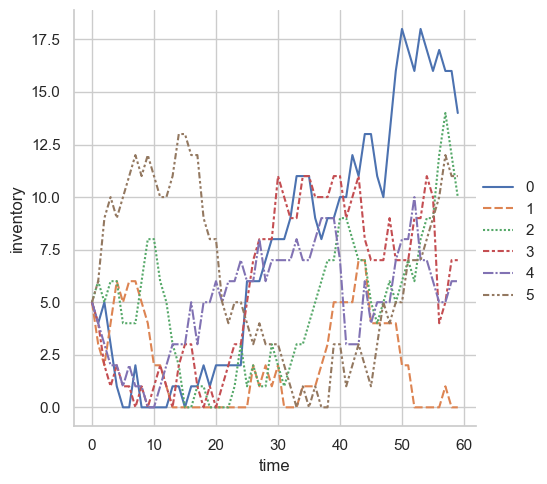

In [3]:
# we plot the number of bikes available over time for 6 simulation paths
sns.set(style="whitegrid")
data = pd.DataFrame(simulated_inventory.T[:,:6], range(60))
ax = sns.relplot(data=data, kind="line")
ax.set(xlabel='time', ylabel='inventory')

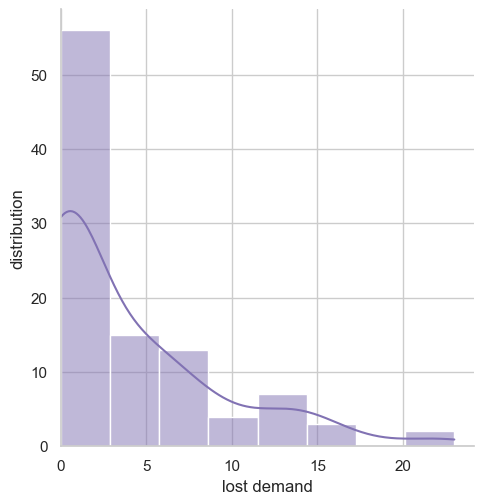

In [4]:
# we plot a histogram and kernel density estimate for the lost demand
ax = sns.displot(lost_demand, color="m",bins=8,kde=True)
ax.set(xlim=(0))
ax.set(xlabel='lost demand', ylabel='distribution');

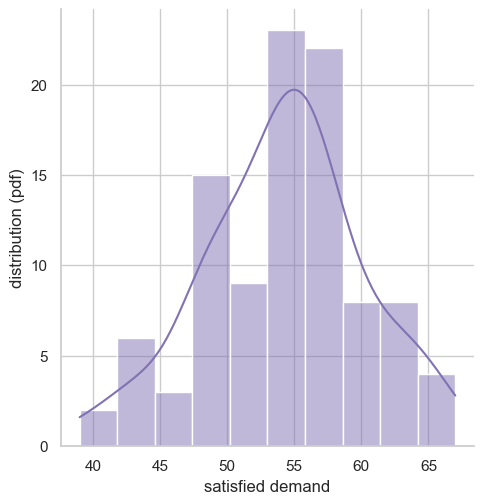

In [5]:
# we plot a histogram and kernel density estimate for the satisfied demand
ax = sns.displot(satisfied_demand, color="m",bins=10,kde=True)
ax.set(xlabel='satisfied demand', ylabel='distribution (pdf)');

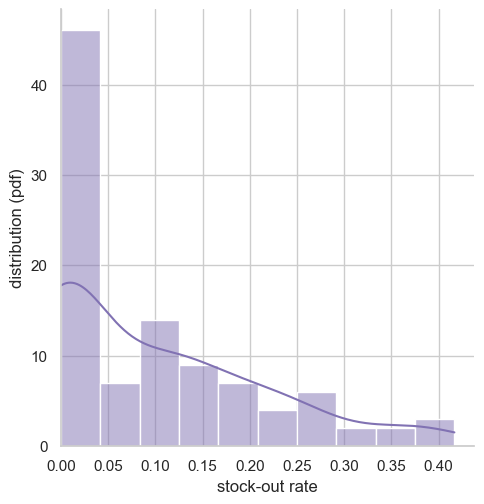

In [6]:
# we plot a histogram and kernel density estimate for the stock-out rate 
ax = sns.displot(is_stock_out/60, color="m",bins=10,kde=True)
ax.set(xlim=(0))
ax.set(xlabel='stock-out rate', ylabel='distribution (pdf)');

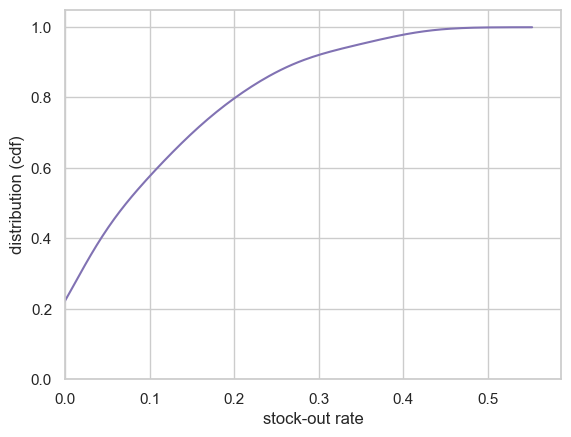

In [7]:
# we plot the cdf estimate for the stock-out rate 
ax = sns.kdeplot(is_stock_out/60, color="m",cumulative=True)
ax.set(xlim=(0))
ax.set(xlabel='stock-out rate', ylabel='distribution (cdf)');

###  What is the probability that there is at least one stock-out in the station for a starting inventory of 5, a request rate of 1.0 and a replenishment rate of 1.0?

Based on 100 simulation paths, the probability of at least one stock-out is approximately 75%. This is read from the CDF of the stock-out rate: roughly 25% of simulation paths had a stock-out rate of 0 (no stock-out), so the complementary probability is ~0.75. This is intuitive — with only 5 bikes and a demand rate equal to the replenishment rate, the inventory performs a near-zero drift random walk and frequently hits 0 within the 60-minute peak hour.

###  Plot the distribution of the sample average satisfied demand over samples of 50 simulation paths (`n_sims = 50`) for a starting inventory of 5, a demand rate of 1.0 and a replenishment rate of 1.0. By varying the sample size, what is the minimal sample size so that 95% of the sample averages are (roughly) within 1 unit ?



The distribution of sample average satisfied demand for n_sims = 50 is approximately normal (by CLT), centered around 55, ranging roughly from 53 to 57.

To find the minimum sample size so that 95% of sample averages are within 1 unit, we use the CLT formula:

n ≥ (1.96 · σ)²

The population standard deviation estimated from 10,000 simulations is σ = 6.20. Applying the formula:

n ≥ (1.96 × 6.20)² ≈ 148

This is verified empirically: at n = 148, the observed standard deviation of sample averages is 0.490 ≤ 0.51, confirming that 95% of sample averages fall within 1 unit of the true mean (since 1.96 × 0.490 ≈ 0.96 < 1).

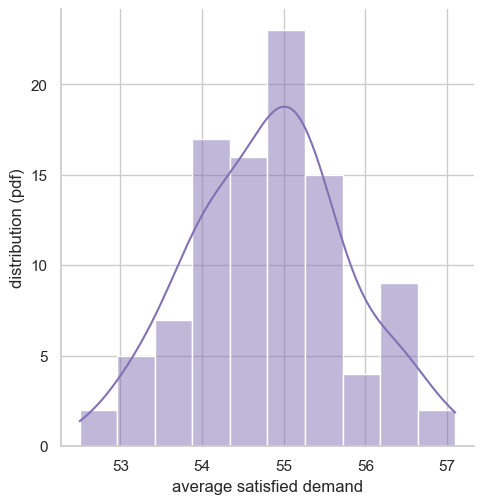

In [8]:
# Code below will plot the distribution for sample size of 50

average_satisfied_demand50 = np.zeros(100)
for t in range(100):
    simulated_inventory,lost_demand,satisfied_demand,is_stock_out = simulate_inventory(1,1,5, n_sims = 50, seed=t)
    average_satisfied_demand50[t] = np.mean(satisfied_demand)
ax = sns.displot(average_satisfied_demand50, color="m",bins=10,kde=True)
ax.set(xlabel='average satisfied demand', ylabel='distribution (pdf)');        

Population std σ = 6.20
Minimum sample size: 148
Observed std of sample averages: 0.490 (target ≤ 0.51)


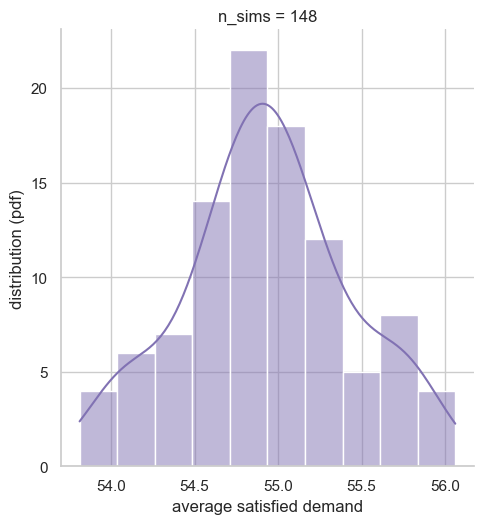

In [9]:
# Insert your code here:
# Step 1: Estimate population std sigma using a large simulation
_, _, sd_pop, _ = simulate_inventory(1, 1, 5, n_sims=10000, seed=0)
sigma = np.std(sd_pop)
print(f"Population std σ = {sigma:.2f}")

# Step 2: Apply CLT formula: need 1.96 * σ/√n ≤ 1  =>  n ≥ (1.96σ)²
min_n = int(np.ceil((1.96 * sigma)**2))
print(f"Minimum sample size: {min_n}")

# Step 3: Verify by plotting the distribution at the minimum sample size
average_satisfied_demand_min = np.zeros(100)
for t in range(100):
    _, _, satisfied_demand, _ = simulate_inventory(1, 1, 5, n_sims=min_n, seed=t)
    average_satisfied_demand_min[t] = np.mean(satisfied_demand)

ax = sns.displot(average_satisfied_demand_min, color="m", bins=10, kde=True)
ax.set(xlabel='average satisfied demand', ylabel='distribution (pdf)')
ax.set(title=f'n_sims = {min_n}')
print(f"Observed std of sample averages: {np.std(average_satisfied_demand_min):.3f} (target ≤ 0.51)")


### Fix the request rate to 1.0 and the sample size to 600. Plot the average satisfied demand as a function of inventory by varying the inventory from 0 to 50 (by increments of 1) and by varying the replenishment rate in $\{0.5,1.0,2.0\}$. 

/var/folders/fv/4_qw2kw56mbdd2r9lbkj4dhm0000gn/T/ipykernel_30189/1831241343.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.lineplot(x="starting inventory", y="satisfied demand", data=df, ci=95)


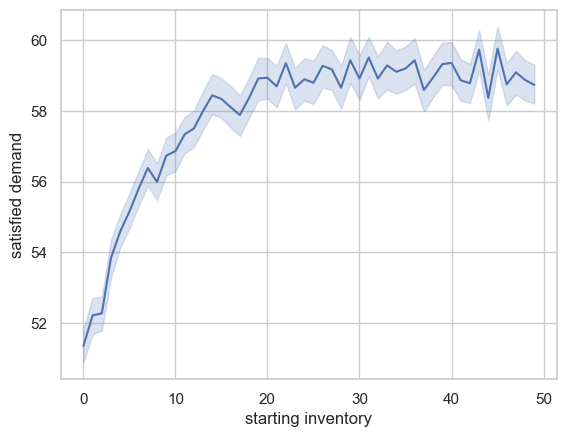

In [10]:
# Code below will plot the satisfied demand with a replenishment of 1

average_satisfied_demand = np.zeros((50,600))
for t in range(50):
    simulated_inventory,lost_demand,satisfied_demand,is_stock_out = simulate_inventory(1,1,t, n_sims = 600, seed=t)
    average_satisfied_demand[t,:] = satisfied_demand

df = pd.DataFrame({'satisfied demand':average_satisfied_demand.flatten(), 
                   'starting inventory': np.repeat(np.arange(50),600)})

ax = sns.lineplot(x="starting inventory", y="satisfied demand", data=df, ci=95)

/var/folders/fv/4_qw2kw56mbdd2r9lbkj4dhm0000gn/T/ipykernel_30189/4256755639.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.lineplot(x="starting inventory", y="satisfied demand",


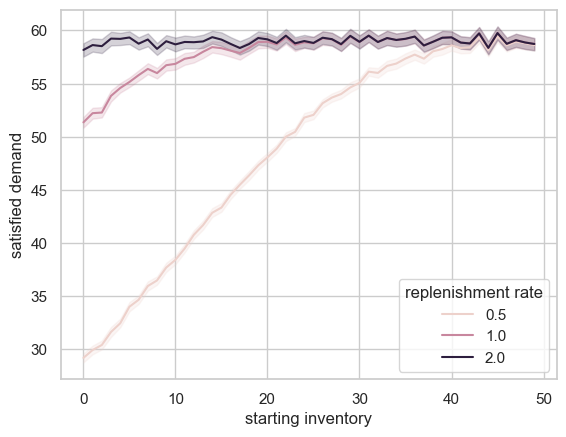

In [11]:
# Insert your code here:
# Plot satisfied demand for replenishment rates 0.5, 1.0, and 2.0
all_data = []

for rep_rate in [0.5, 1.0, 2.0]:
    avg_sd = np.zeros((50, 600))
    for t in range(50):
        _, _, satisfied_demand, _ = simulate_inventory(1, rep_rate, t, n_sims=600, seed=t)
        avg_sd[t, :] = satisfied_demand
    
    df_temp = pd.DataFrame({
        'satisfied demand': avg_sd.flatten(),
        'starting inventory': np.repeat(np.arange(50), 600),
        'replenishment rate': rep_rate
    })
    all_data.append(df_temp)

df_all = pd.concat(all_data)

ax = sns.lineplot(x="starting inventory", y="satisfied demand", 
                  hue="replenishment rate", data=df_all, ci=95)



The plot shows average satisfied demand as a function of starting inventory for three replenishment rates. Higher replenishment rates lead to significantly higher satisfied demand at low inventory levels, as returned bikes replenish stock before demand arrives. At high inventory (≥30–40), all three curves converge to the same ceiling (~59), since inventory is no longer the binding constraint.

###  If we increase inventory by 1 unit, by how much does the demand increase? Answer qualitatively.


The effect is diminishing and depends on the replenishment rate:

At low inventory, adding 1 unit has a large positive effect — the curves are steep, meaning each extra bike meaningfully reduces lost demand. The effect is largest for replenishment rate = 0.5 (lightest line, steepest slope at low inventory).
At high inventory (≥ ~20–30 for rates 1.0 and 2.0, ≥ ~40 for rate 0.5), the curves flatten out — adding 1 more bike has near-zero effect since stock-outs are already rare.
In other words, there are decreasing returns to inventory: the marginal benefit of one extra bike shrinks as inventory grows, eventually reaching zero once the station is sufficiently stocked relative to demand.